<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day09-backprop-training-regularization.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 9 — Backpropagation, Training, and Regularization, in code

This notebook rebuilds Day 8's exact subcellular-localization dataset
and network (self-contained, so this notebook runs on its own), then
does what Day 8 deliberately stopped short of: implements the standard
PyTorch training loop, demonstrates *why* deep networks with saturating
activations are hard to train (the vanishing-gradient problem), applies
dropout/L2/early-stopping to fight overfitting, and reports the trained
model's real accuracy — directly comparable to Day 8's untrained
baseline.

In [1]:
import re
import numpy as np
import requests
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, matthews_corrcoef,
)

torch.manual_seed(0)
np.random.seed(0)

## Rebuilding Day 8's dataset and model

Identical to Day 8's notebook: fetch the same five UniProt subcellular-
location classes, keep only unambiguous single-location entries, balance
the classes, one-hot encode (150 residues x 20 amino acids, flattened),
and split train/val/test the same way.

In [2]:
UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))
    return rows

def is_unambiguous_single_location(location_text, target):
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip()
        if top_term:
            terms.add(top_term)
    return len(terms) == 1 and next(iter(terms)) == target

sequences_by_class = {}
for class_name, sl_code in UNIPROT_CLASSES.items():
    raw = fetch_uniprot(sl_code)
    clean = [seq for _, seq, loc in raw if is_unambiguous_single_location(loc, class_name)]
    sequences_by_class[class_name] = clean

N_PER_CLASS = min(len(v) for v in sequences_by_class.values())
rng = np.random.RandomState(0)
balanced_seqs, balanced_labels = [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = sequences_by_class[class_name]
    chosen = rng.choice(len(pool), N_PER_CLASS, replace=False)
    for i in chosen:
        balanced_seqs.append(pool[i])
        balanced_labels.append(class_idx)

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded.flatten()

X = np.stack([one_hot_encode(s) for s in balanced_seqs])
y = np.array(balanced_labels)

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=0)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

print(f"dataset rebuilt: {len(balanced_seqs)} sequences, {N_PER_CLASS} per class")
print(f"train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")


class SubcellularLocalizationClassifier(nn.Module):
    def __init__(self, input_dim=SEQ_LEN * len(AMINO_ACIDS), hidden_dim=64, n_classes=5, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)

print("model class ready:", SubcellularLocalizationClassifier().net)

dataset rebuilt: 700 sequences, 140 per class
train: 490   val: 105   test: 105
model class ready: Sequential(
  (0): Linear(in_features=3000, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.0, inplace=False)
  (3): Linear(in_features=64, out_features=5, bias=True)
)


## Backpropagation: the chain rule, layer by layer

Day 1 introduced the chain rule; a network with a hidden layer is
exactly a composition of functions, $\hat y = f_2(f_1(x))$, so training
it needs the loss's derivative with respect to *every* weight in *both*
layers. Backpropagation is not a different algorithm from the chain rule
— it is the chain rule, applied systematically from the output layer
backward to the input layer, reusing each layer's already-computed
derivative rather than recomputing it from scratch. PyTorch's
`loss.backward()` does exactly this automatically for a graph of any
depth; that automation is *why* a framework rather than hand-written
gradient descent (as in Day 6's from-scratch notebook) becomes essential
once a model has more than one layer.

### Further reading

- Wikipedia, [Backpropagation](https://en.wikipedia.org/wiki/Backpropagation)

## The standard PyTorch training loop

Four steps, repeated: **forward pass** (compute predictions), **compute
loss**, **`loss.backward()`** (backpropagation — fills in every weight's
gradient), **`optimizer.step()`** (updates every weight using its
gradient). First, without any regularization, to see what happens:

In [3]:
torch.manual_seed(0)
model_plain = SubcellularLocalizationClassifier(dropout=0.0)
optimizer = torch.optim.Adam(model_plain.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

history = []
for epoch in range(30):
    model_plain.train()
    optimizer.zero_grad()
    logits = model_plain(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model_plain.eval()
    with torch.no_grad():
        train_acc = (model_plain(X_train_t).argmax(1).numpy() == y_train).mean()
        val_acc = (model_plain(X_val_t).argmax(1).numpy() == y_val).mean()
    history.append((epoch, loss.item(), train_acc, val_acc))
    if epoch % 5 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}: loss {loss.item():.3f}   train acc {train_acc:.3f}   val acc {val_acc:.3f}")

epoch  0: loss 1.613   train acc 0.522   val acc 0.295
epoch  5: loss 1.265   train acc 0.988   val acc 0.514
epoch 10: loss 0.880   train acc 0.994   val acc 0.505
epoch 15: loss 0.550   train acc 0.998   val acc 0.524
epoch 20: loss 0.317   train acc 0.998   val acc 0.543
epoch 25: loss 0.175   train acc 1.000   val acc 0.543
epoch 29: loss 0.109   train acc 1.000   val acc 0.543


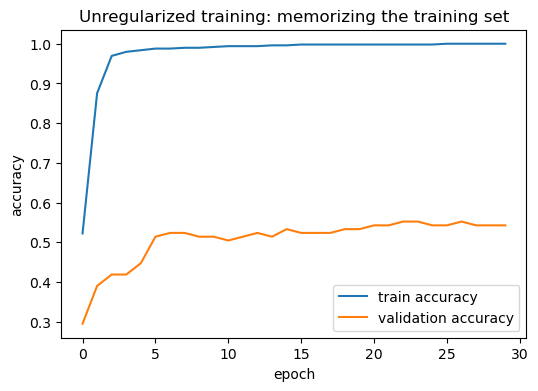

final train accuracy: 1.000   final val accuracy: 0.543


In [4]:
import matplotlib.pyplot as plt
epochs, losses, train_accs, val_accs = zip(*history)
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, label="train accuracy")
plt.plot(epochs, val_accs, label="validation accuracy")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("Unregularized training: memorizing the training set")
plt.show()
print(f"final train accuracy: {train_accs[-1]:.3f}   final val accuracy: {val_accs[-1]:.3f}")

Training accuracy reaches essentially 100% while validation accuracy
plateaus far below it — classic **overfitting**. This dataset makes it
almost inevitable: 490 training examples against a 3000-dimensional
input and ~190,000 parameters gives the network far more freedom than
data, so it memorizes idiosyncrasies of the specific training sequences
rather than learning the general signal. This is exactly the problem the
regularization techniques below exist to fight.

### Further reading

- Wikipedia, [Overfitting](https://en.wikipedia.org/wiki/Overfitting)

## Vanishing gradients: why activation choice matters for depth

Sigmoid and tanh saturate (flatten) for large $|x|$ (Day 8), so their
derivative there is near zero. In a deep network, the chain rule
*multiplies* these derivatives together across layers — a handful of
small numbers multiplied together compounds fast. A concrete check: a
6-hidden-layer network, once with sigmoid activations and once with
ReLU, both freshly initialized, one backward pass each, comparing the
average gradient magnitude reaching each layer's weights (layer 1 =
closest to the input, most affected by the chain of multiplications):

In [5]:
class DeepNet(nn.Module):
    def __init__(self, activation_cls, depth=6, width=64, input_dim=SEQ_LEN * len(AMINO_ACIDS)):
        super().__init__()
        layers, d = [], input_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), activation_cls()]
            d = width
        layers += [nn.Linear(width, 5)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

loss_fn = nn.CrossEntropyLoss()
for name, activation_cls in [("sigmoid", nn.Sigmoid), ("ReLU", nn.ReLU)]:
    torch.manual_seed(0)
    net = DeepNet(activation_cls)
    logits = net(X_train_t)
    loss = loss_fn(logits, y_train_t)
    weight_params = [p for p in net.parameters() if p.dim() == 2]
    grads = torch.autograd.grad(loss, weight_params)
    magnitudes = [g.abs().mean().item() for g in grads]
    print(f"{name:8s} mean |gradient| per layer, input-side first:")
    print("        ", [f"{m:.2e}" for m in magnitudes])
    print(f"        ratio (output layer / input layer): {magnitudes[-1] / magnitudes[0]:.0f}x")
    print()

sigmoid  mean |gradient| per layer, input-side first:
         ['8.33e-09', '3.15e-07', '2.04e-06', '1.63e-05', '1.21e-04', '9.36e-04', '2.60e-02']
        ratio (output layer / input layer): 3122336x

ReLU     mean |gradient| per layer, input-side first:
         ['4.17e-06', '3.93e-06', '3.62e-06', '7.30e-06', '1.82e-05', '3.79e-05', '5.49e-04']
        ratio (output layer / input layer): 132x



With sigmoid, the gradient reaching the layer closest to the input is
roughly **three million times smaller** than the gradient reaching the output
layer — that layer's weights would barely move under gradient descent,
even though it still needs to learn something useful. ReLU's gradients
shrink far less across the same depth, which is why it (or variants of
it) is the default choice for hidden layers in modern networks.

The three main tools against this, alongside choosing ReLU-like
activations: **weight initialization** schemes that start each layer's
weights at a scale matched to its size (avoiding saturation from the
very first forward pass), **input standardization** (centering/scaling
inputs so no single feature dominates), and **batch normalization**
(normalizing the *activations* between layers during training, so later
layers don't have to keep adapting to a shifting input distribution). This
network's input is already binary one-hot (already on a fixed, bounded
scale), so standardization matters less here than it would for a network
with raw continuous inputs — worth knowing, not always worth applying
blindly.

### Further reading

- Wikipedia, [Vanishing gradient problem](https://en.wikipedia.org/wiki/Vanishing_gradient_problem)
- Ioffe & Szegedy (2015), "Batch Normalization," [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

## Regularization: dropout, L2, and early stopping

Three practical tools against the overfitting seen above:

- **Dropout** randomly zeroes a fraction of a layer's activations during
  each training step, preventing the network from relying too heavily on
  any single unit.
- **L2 regularization** (a.k.a. weight decay) adds a penalty proportional
  to the *square* of the weights to the loss, discouraging any single
  weight from growing large; PyTorch applies it via the optimizer's
  `weight_decay` argument, not a separate loss term. **L1 regularization**
  (Lasso) uses the *absolute value* instead, and tends to push some
  weights to exactly zero rather than just shrinking all of them.
- **Early stopping** — simply not training past the epoch where
  validation performance peaks — costs nothing extra to implement and is
  often the single most effective fix.

In [6]:
torch.manual_seed(0)
model_reg = SubcellularLocalizationClassifier(dropout=0.5)
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3, weight_decay=1e-3)  # L2 via weight_decay
loss_fn = nn.CrossEntropyLoss()

best_val_acc, best_epoch, best_state = 0.0, 0, None
history_reg = []
for epoch in range(100):
    model_reg.train()
    optimizer.zero_grad()
    logits = model_reg(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model_reg.eval()
    with torch.no_grad():
        train_acc = (model_reg(X_train_t).argmax(1).numpy() == y_train).mean()
        val_acc = (model_reg(X_val_t).argmax(1).numpy() == y_val).mean()
    history_reg.append((epoch, train_acc, val_acc))
    if val_acc > best_val_acc:
        best_val_acc, best_epoch = val_acc, epoch
        best_state = {k: v.clone() for k, v in model_reg.state_dict().items()}

print(f"best validation accuracy: {best_val_acc:.3f}, reached at epoch {best_epoch}")
print(f"training accuracy at end of the full 100-epoch run: {history_reg[-1][1]:.3f}")
model_reg.load_state_dict(best_state)  # roll back to the early-stopped weights

best validation accuracy: 0.590, reached at epoch 29
training accuracy at end of the full 100-epoch run: 1.000


<All keys matched successfully>

Dropout and L2 alone give only a modest improvement here — training
accuracy still reaches 100%, since with ~190,000 parameters and 490
training examples the model has enough capacity to memorize the training
set regardless. **Early stopping** (rolling back to the epoch with the
best validation accuracy, done above) is what actually captures the
improvement in practice. Honestly reported: regularization helps, but it
is not a substitute for having enough data relative to model size — a
real limitation of this small, deliberately simple case study, and part
of why production tools for this exact problem (e.g. DeepLoc) use much
larger training sets and more parameter-efficient input representations
than a flattened one-hot encoding.

### Further reading

- Wikipedia, [Regularization (mathematics)](https://en.wikipedia.org/wiki/Regularization_(mathematics)), [Dropout (neural networks)](https://en.wikipedia.org/wiki/Dropout_(neural_networks)), [Early stopping](https://en.wikipedia.org/wiki/Early_stopping)

## Evaluating the trained model

The same four metrics from Day 8, now on this early-stopped, regularized
model's real predictions — directly comparable to Day 8's untrained
baseline (accuracy 0.248, MCC 0.086, macro AUROC 0.542):

In [7]:
model_reg.eval()
with torch.no_grad():
    val_logits = model_reg(X_val_t)
predicted_classes = val_logits.argmax(dim=1).numpy()
predicted_probs = torch.softmax(val_logits, dim=1).numpy()

accuracy = (predicted_classes == y_val).mean()
print(f"accuracy: {accuracy:.3f}  (Day 8's untrained baseline: 0.248; chance: 0.20)")

cm = confusion_matrix(y_val, predicted_classes)
print("\nconfusion matrix (rows = true class, columns = predicted class):")
print("classes:", CLASS_NAMES)
print(cm)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_val, predicted_classes, average="macro", zero_division=0
)
print(f"\nmacro precision: {precision:.3f}   macro recall: {recall:.3f}   macro F1: {f1:.3f}")

mcc = matthews_corrcoef(y_val, predicted_classes)
print(f"MCC: {mcc:.3f}  (Day 8's untrained baseline: 0.086)")

auroc = roc_auc_score(y_val, predicted_probs, multi_class="ovr")
print(f"macro AUROC: {auroc:.3f}  (Day 8's untrained baseline: 0.542)")

accuracy: 0.590  (Day 8's untrained baseline: 0.248; chance: 0.20)

confusion matrix (rows = true class, columns = predicted class):
classes: ['Cytoplasm', 'Nucleus', 'Mitochondrion', 'Secreted', 'Cell membrane']
[[ 8  6  1  2  4]
 [ 3 11  2  4  1]
 [ 1  3 14  1  2]
 [ 0  3  1 12  5]
 [ 2  0  2  0 17]]

macro precision: 0.593   macro recall: 0.590   macro F1: 0.584
MCC: 0.492  (Day 8's untrained baseline: 0.086)
macro AUROC: 0.828  (Day 8's untrained baseline: 0.542)


Every metric improves substantially over Day 8's untrained baseline —
real training, on a real biological dataset, doing real work.

## The payoff: what this whole arc was building toward

Trace the pieces back: Day 5 introduced the profile/PSSM score as a
weighted sum over sequence positions — already a linear model. Day 6
formalized that as a perceptron, showed its weights can be *learned*
rather than derived, and demonstrated a real limitation (the XOR-shaped
Bulyk et al. example) that only a **hidden layer** resolves. Day 8 wrote
that hidden-layer model the proper PyTorch way. This notebook just
trained it — with real backpropagation, real regularization — on a real
multi-class biological problem.

Rost & Sander's **PHD** method (already introduced on Day 6) is the same
recipe at the scale that mattered historically: profile input (Day 5) +
a hidden layer (Day 6) + a trained feed-forward network (this notebook's
training loop) + a 3-class softmax output (helix / sheet / coil — Day
8's softmax section) trained on real protein structures. That combination
is what pushed single-sequence secondary-structure prediction past the
60-65% plateau to over 70% accuracy in the early 1990s — the same
Rost & Sander (1993) result already cited on Day 6, now with every piece
of the machinery behind it fully explained rather than taken on faith.

## Try it yourself

Try `weight_decay=0` (no L2) with dropout still on, or vice versa, and
compare the best validation accuracy and the epoch it's reached at.
Try `hidden_dim=16` instead of 64 in `SubcellularLocalizationClassifier`
— a smaller model has less capacity to overfit in the first place; does
it need as much help from regularization to reach a similar validation
accuracy?